In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the robot data
robot_df = pd.read_csv("Classification_of_Robots_from_their_conversation_sequence.csv")

# Separate features and target variable
X = robot_df.iloc[:, 1:]  # Features: num1 to num10
y = robot_df.iloc[:, 0]   # Target: robotID (classification labels)

# Add prefix "Robot" to target labels and encode them
y = y.astype(str).apply(lambda x: f"Robot{x}")  # Prefix "Robot"
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Convert to numeric labels

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [2]:
# Normalize the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [3]:
def train_KNN_model(neighbors: int, X_train_scaled, y_train, X_test_scaled, y_test, class_labels=None):
    """Train a KNN model, evaluate its performance, and visualize results."""
    
    # Train KNN model
    knn = KNeighborsClassifier(n_neighbors=neighbors)
    knn.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = knn.predict(X_test_scaled)

    # Compute Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_labels if len(class_labels) > 0 else range(len(conf_matrix)), 
                yticklabels=class_labels if len(class_labels) > 0 else range(len(conf_matrix)))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"KNN (k={neighbors}) - Confusion Matrix")
    plt.show()

    # Accuracy Score
    accuracy = accuracy_score(y_test, y_pred)

    # Sensitivity (Recall Macro-Averaged)
    sensitivity = recall_score(y_test, y_pred, average='macro')

    # F1 Score Calculation
    f1 = f1_score(y_test, y_pred, average='macro')

    # Specificity Calculation
    specificity_list = []
    for i in range(len(conf_matrix)):
        tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
        fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_list.append(specificity)
    specificity = np.mean(specificity_list)

    # Print Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity (Macro Recall): {sensitivity:.4f}")
    print(f"Specificity (Macro Specificity): {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


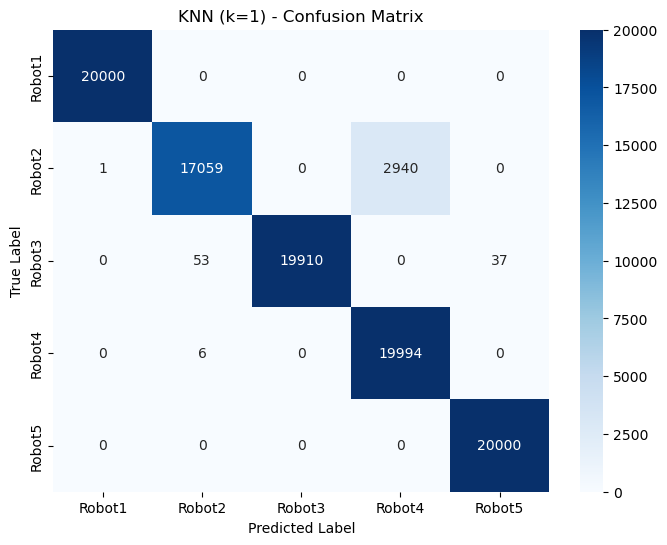

Accuracy: 0.9696
Sensitivity (Macro Recall): 0.9696
Specificity (Macro Specificity): 0.9924
F1 Score: 0.9695

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     20000
           1       1.00      0.85      0.92     20000
           2       1.00      1.00      1.00     20000
           3       0.87      1.00      0.93     20000
           4       1.00      1.00      1.00     20000

    accuracy                           0.97    100000
   macro avg       0.97      0.97      0.97    100000
weighted avg       0.97      0.97      0.97    100000



In [4]:
train_KNN_model(1, X_train_scaled,y_train,X_test_scaled,y_test,label_encoder.classes_)

In [5]:
neighbor_accuracy = {}
for neighbor in range(1,11):
    # Train KNN model (fix: train on scaled features)
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = knn.predict(X_test_scaled)
    # Accuracy Score
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Neighbor: {neighbor}.Accuracy: {accuracy:.4f}")
    neighbor_accuracy[neighbor] = accuracy

Neighbor: 1.Accuracy: 0.9696
Neighbor: 2.Accuracy: 0.9688
Neighbor: 3.Accuracy: 0.9372
Neighbor: 4.Accuracy: 0.9357
Neighbor: 5.Accuracy: 0.9022
Neighbor: 6.Accuracy: 0.8992
Neighbor: 7.Accuracy: 0.8675
Neighbor: 8.Accuracy: 0.8628
Neighbor: 9.Accuracy: 0.8368
Neighbor: 10.Accuracy: 0.8325


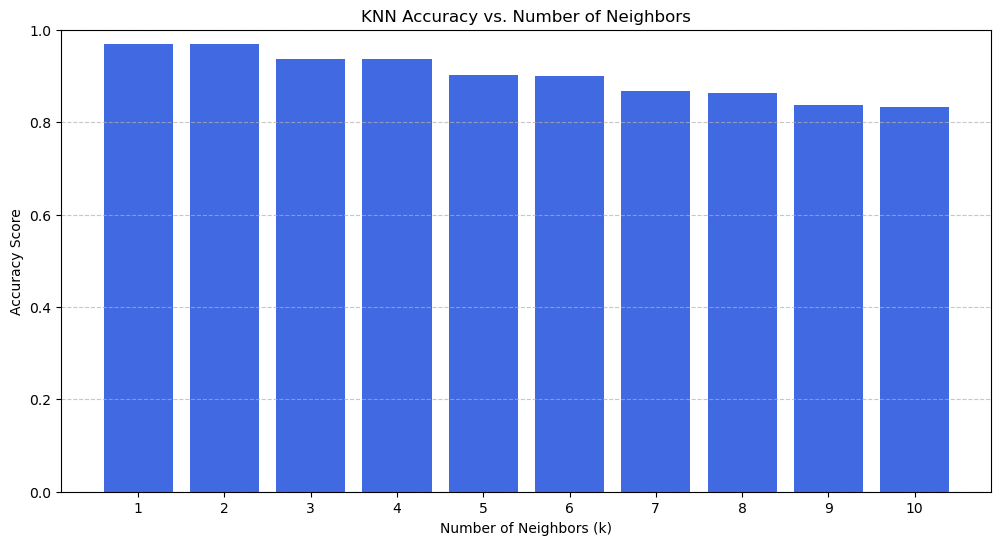

In [6]:
# Create a bar graph that put neighbor in x and accuracy on y
# Plot Bar Graph
plt.figure(figsize=(12,6))
plt.bar(neighbor_accuracy.keys(), neighbor_accuracy.values(), color='royalblue')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy Score")
plt.title("KNN Accuracy vs. Number of Neighbors")
plt.xticks(range(1, 11))  # Ensure x-axis shows k values from 1 to 10
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()